# Environment Test: PRB Cap And Service Metrics

This notebook checks the environment fix for the bad training signal where one UE can consume `100%` of a slice budget.

It compares two runs on the same 3-gNodeB topology:

- `uncapped`: old behavior, no per-UE PRB cap.
- `capped_20`: one UE can receive at most `20` PRBs per scheduler tick.

Each gNodeB has `150` PRBs, divided as `50 eMBB`, `50 URLLC`, and `50 mMTC`.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from global_ppo_3gnb_env import GLOBAL_SNAPSHOT_SCENARIOS, GlobalPPO3GNBEnv, SLICE_TYPES

plt.rcParams.update({"figure.dpi": 125, "axes.grid": True, "grid.alpha": 0.22})
np.set_printoptions(precision=3, suppress=True)

GNB_IDS = (0, 1, 2)
GNB_NAMES = [f"gNB {g}" for g in GNB_IDS]

In [2]:
SEED = 23
SCENARIO_NAME = "multi_slice_multi_gnb_congestion"
N_WINDOWS = 3
LOCAL_STEPS_PER_GLOBAL = 8
MAX_HANDOVERS_PER_LOCAL_STEP = 2

TOTAL_PRBS_PER_GNB = 150
SLICE_PRB_BUDGETS = {"eMBB": 50, "URLLC": 50, "mMTC": 50}

GNB_CONFIGS_3_150 = [
    {"id": 0, "x": 0.0, "y": 0.0, "coverage_radius": 560.0, "carrier_id": 0, "n_prbs": TOTAL_PRBS_PER_GNB},
    {"id": 1, "x": 430.0, "y": 0.0, "coverage_radius": 560.0, "carrier_id": 0, "n_prbs": TOTAL_PRBS_PER_GNB},
    {"id": 2, "x": 215.0, "y": 372.0, "coverage_radius": 560.0, "carrier_id": 0, "n_prbs": TOTAL_PRBS_PER_GNB},
]

TARGET_LOAD_MATRIX = GLOBAL_SNAPSHOT_SCENARIOS[SCENARIO_NAME].copy()
BIAS_MATRIX = np.where(
    TARGET_LOAD_MATRIX >= 0.80,
    -0.75,
    np.where(TARGET_LOAD_MATRIX <= 0.35, 0.55, 0.0),
).astype(float)

display(pd.DataFrame(TARGET_LOAD_MATRIX, index=GNB_NAMES, columns=SLICE_TYPES).style.set_caption("Snapshot target loads"))
display(pd.DataFrame(BIAS_MATRIX, index=GNB_NAMES, columns=SLICE_TYPES).style.set_caption("Fixed heuristic bias"))

,eMBB,URLLC,mMTC
gNB 0,0.920000,0.860000,0.350000
gNB 1,0.320000,0.900000,0.880000
gNB 2,0.760000,0.300000,0.280000


,eMBB,URLLC,mMTC
gNB 0,-0.750000,-0.750000,0.550000
gNB 1,0.550000,-0.750000,-0.750000
gNB 2,0.000000,0.550000,0.550000


In [3]:
def make_env(max_prbs_per_ue):
    return GlobalPPO3GNBEnv(
        seed=SEED,
        n_gnbs=3,
        include_ue_counts=True,
        include_service_metrics=True,
        use_sumo_mobility=False,
        local_steps_per_global=LOCAL_STEPS_PER_GLOBAL,
        global_steps_per_episode=N_WINDOWS,
        radio_substeps=1,
        gnb_configs=GNB_CONFIGS_3_150,
        scenario_mode="snapshot",
        snapshot_scenario=SCENARIO_NAME,
        terminal_reward_only=False,
        use_progress_reward=False,
        max_handovers_per_local_step=MAX_HANDOVERS_PER_LOCAL_STEP,
        slice_prb_budgets=SLICE_PRB_BUDGETS,
        max_prbs_per_ue=max_prbs_per_ue,
    )


def load_matrix(env):
    return np.asarray(env._load_matrix(), dtype=float)


def kpi_frame(env):
    rows = []
    for (gnb_id, slice_type), kpi in sorted(env.base_env._last_info.get("slice_kpis", {}).items()):
        row = {"gnb_id": gnb_id, "slice_type": slice_type}
        row.update(kpi)
        rows.append(row)
    return pd.DataFrame(rows)


def run_case(name, max_prbs_per_ue):
    env = make_env(max_prbs_per_ue)
    obs, info = env.reset(seed=SEED)
    before = load_matrix(env)
    trace = []
    for window in range(N_WINDOWS):
        obs, reward, terminated, truncated, info = env.step(BIAS_MATRIX.reshape(-1))
        trace.append({
            "case": name,
            "window": window,
            "reward": float(reward),
            "handover_count": int(info["handover_count"]),
            "target_load_error": float(info["target_load_error"]),
            "obs_dim": int(obs.size),
        })
        if terminated or truncated:
            break
    after = load_matrix(env)
    kpis = kpi_frame(env)
    env.close()
    return {"name": name, "before": before, "after": after, "trace": pd.DataFrame(trace), "kpis": kpis}


results = {
    "uncapped": run_case("uncapped", None),
    "capped_20": run_case("capped_20", 20),
}

## Summary

In [4]:
summary_rows = []
for name, result in results.items():
    kpis = result["kpis"]
    one_ue = kpis[kpis["ue_count"] == 1]
    final = result["trace"].iloc[-1]
    summary_rows.append({
        "case": name,
        "total_handovers": int(result["trace"]["handover_count"].sum()),
        "final_target_load_error": final["target_load_error"],
        "max_single_ue_allocated_load": one_ue["allocated_load"].max() if not one_ue.empty else np.nan,
        "max_allocated_load": kpis["allocated_load"].max(),
        "max_demand_load": kpis["demand_load"].max(),
        "max_queue_pressure": kpis["queue_pressure"].max(),
        "min_tx_success_ratio": kpis["tx_success_ratio"].min(),
        "obs_dim": int(final["obs_dim"]),
    })

summary = pd.DataFrame(summary_rows)
display(summary)

assert summary.loc[summary["case"] == "capped_20", "max_single_ue_allocated_load"].iloc[0] <= 0.40 + 1e-9

,case,total_handovers,final_target_load_error,max_single_ue_allocated_load,max_allocated_load,max_demand_load,max_queue_pressure,min_tx_success_ratio,obs_dim
0,uncapped,28,0.154181,1.0,1.0,29.24,2.328526,0.0,54
1,capped_20,28,0.074419,0.4,1.0,29.24,2.328526,0.0,54


## Final Slice KPIs

In [5]:
KPI_COLUMNS = [
    "gnb_id", "slice_type", "ue_count", "budget_prbs", "allocated_prbs", "allocated_load",
    "demand_prbs", "demand_load", "queue_bits", "queue_pressure", "arrived_bits",
    "scheduled_bits", "served_bits", "served_ratio", "service_to_arrival_ratio", "tx_success_ratio",
    "delay_s", "dropped_bits",
]

for name, result in results.items():
    print("\n===", name, "===")
    display(result["kpis"][KPI_COLUMNS].sort_values(["gnb_id", "slice_type"]))


=== uncapped ===


,gnb_id,slice_type,ue_count,budget_prbs,allocated_prbs,allocated_load,demand_prbs,demand_load,queue_bits,queue_pressure,arrived_bits,scheduled_bits,served_bits,served_ratio,service_to_arrival_ratio,tx_success_ratio,delay_s,dropped_bits
0,0,URLLC,1,50,12,0.24,0,0.00,0.000000,0.000000,2054.000000,2054.0,2054.0,1.000000,1.000000,1.000000,0.00000,0.0
1,0,eMBB,1,50,16,0.32,1,0.02,0.800000,0.000016,5308.800000,5309.0,5309.0,1.000000,1.000038,1.000000,0.00000,0.0
2,0,mMTC,2,50,50,1.00,177,3.54,11123.800000,0.075801,14884.800000,16016.0,14000.0,0.940557,0.940557,0.874126,0.00600,0.0
3,1,URLLC,4,50,50,1.00,727,14.54,68989.200000,1.422745,5024.400000,5862.0,822.0,0.163602,0.163602,0.140225,0.01225,0.0
4,1,eMBB,2,50,50,1.00,1462,29.24,229574.000036,2.328526,9585.333335,13758.0,0.0,0.000000,0.000000,0.000000,0.02250,0.0
5,1,mMTC,1,50,50,1.00,53,1.06,13272.333365,0.500013,2738.666668,12600.0,0.0,0.000000,0.000000,0.000000,0.00400,0.0
6,2,URLLC,2,50,30,0.60,1,0.02,0.800000,0.000006,12084.800000,12084.0,12084.0,0.999934,0.999934,1.000000,0.00000,0.0
7,2,eMBB,3,50,50,1.00,637,12.74,326554.800000,1.355636,23984.400000,19590.0,19590.0,0.816781,0.816781,1.000000,0.01300,0.0
8,2,mMTC,2,50,50,1.00,379,7.58,26282.400000,0.449701,6035.600000,6244.0,3976.0,0.658758,0.658758,0.636771,0.01050,0.0



=== capped_20 ===


,gnb_id,slice_type,ue_count,budget_prbs,allocated_prbs,allocated_load,demand_prbs,demand_load,queue_bits,queue_pressure,arrived_bits,scheduled_bits,served_bits,served_ratio,service_to_arrival_ratio,tx_success_ratio,delay_s,dropped_bits
0,0,URLLC,1,50,12,0.24,0,0.00,0.000000,0.000000,2054.000000,2054.0,2054.0,1.000000,1.000000,1.000000,0.00000,0.0
1,0,eMBB,1,50,20,0.40,198,3.96,68711.800000,1.342237,5308.800000,6940.0,6940.0,1.000000,1.307263,1.000000,0.01300,0.0
2,0,mMTC,2,50,38,0.76,324,6.48,20476.800000,0.139535,14884.800000,15260.0,14000.0,0.940557,0.940557,0.917431,0.01150,0.0
3,1,URLLC,4,50,50,1.00,592,11.84,71435.200000,1.473188,5024.400000,6114.0,822.0,0.163602,0.163602,0.134446,0.01025,0.0
4,1,eMBB,2,50,40,0.80,1462,29.24,229574.000036,2.328526,9585.333335,11360.0,0.0,0.000000,0.000000,0.000000,0.02250,0.0
5,1,mMTC,1,50,20,0.40,33,0.66,8232.333365,0.310139,2738.666668,5040.0,5040.0,1.000000,1.840312,1.000000,0.00300,0.0
6,2,URLLC,2,50,30,0.60,1,0.02,0.800000,0.000006,12084.800000,12084.0,12084.0,0.999934,0.999934,1.000000,0.00000,0.0
7,2,eMBB,3,50,50,1.00,639,12.78,313658.800000,1.302100,23984.400000,19590.0,19590.0,0.816781,0.816781,1.000000,0.01300,0.0
8,2,mMTC,2,50,40,0.80,759,15.18,126084.400000,2.157347,6035.600000,6940.0,0.0,0.000000,0.000000,0.000000,0.02150,0.0


## Load Matrices

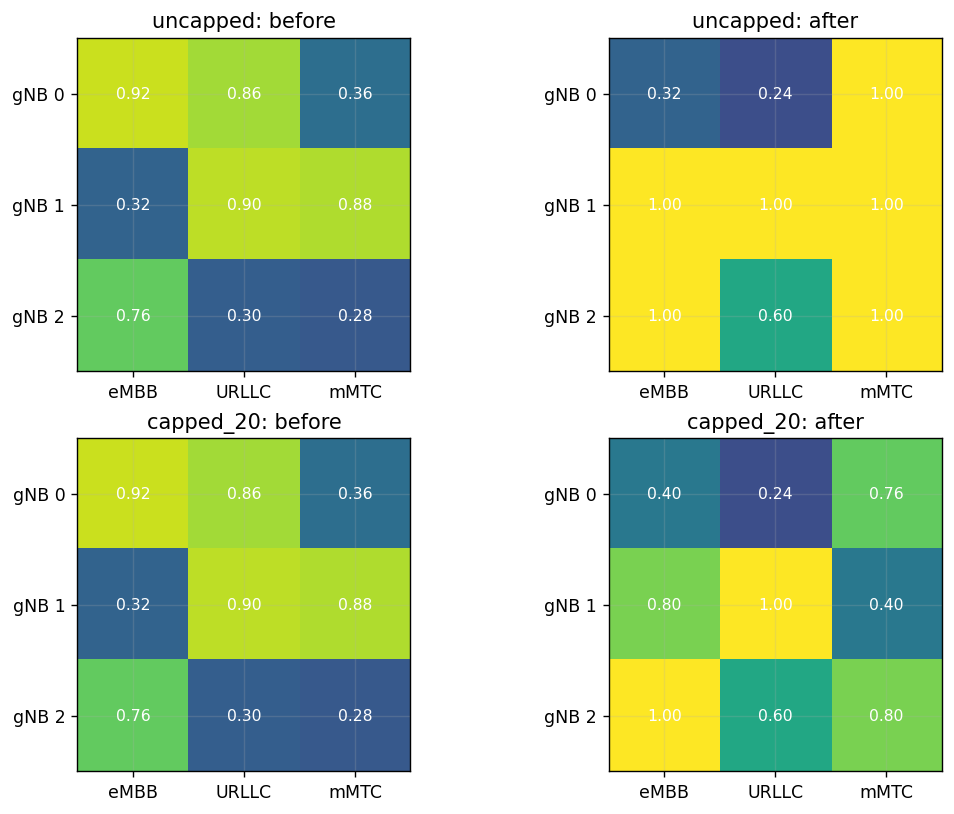

In [6]:
def heatmap(ax, matrix, title, cmap="viridis", vmin=0.0, vmax=1.0):
    matrix = np.asarray(matrix, dtype=float)
    ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(SLICE_TYPES)), SLICE_TYPES)
    ax.set_yticks(range(len(GNB_IDS)), GNB_NAMES)
    ax.set_title(title)
    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, f"{matrix[r, c]:.2f}", ha="center", va="center", color="white", fontsize=9)


fig, axes = plt.subplots(len(results), 2, figsize=(8.5, 3.2 * len(results)), constrained_layout=True)
if len(results) == 1:
    axes = np.asarray([axes])

for row, (name, result) in enumerate(results.items()):
    heatmap(axes[row, 0], result["before"], f"{name}: before")
    heatmap(axes[row, 1], result["after"], f"{name}: after")

plt.show()